# Customer Segmentation with RFM and Clustering

## Project question

Can customers of an online retailer be separated into useful behavioral groups using only their transaction history? This notebook compares K-Means, Ward hierarchical clustering, and DBSCAN, then uses the selected model to build customer profiles.

The data comes from the [UCI Online Retail II dataset](https://doi.org/10.24432/C5CG6D) and covers transactions from December 2009 to December 2011.

## Short answer

- The **highest-silhouette split** is K-Means with K=2 (`silhouette = 0.4385`). It separates broadly active/high-value customers from less active/low-value customers.
- **K-Means with K=4** is kept as the final operational solution. It is not the metric winner, but it produces four balanced, repeatable, and interpretable profiles when the multi-start project setting is used.
- The selected practical DBSCAN setting has a negative **DBCV** score (about `-0.63`). Its density groups are not well separated, and its noise group contains commercially valuable customers rather than obvious bad records.
- In the time-based extension, customers seen in the first 365-day period have a **63.6%** purchase retention rate. They generate **82.1%** of gross purchase value in the following period.

This is an unsupervised analysis. The segment names are descriptions of observed purchasing behavior, not permanent customer identities.

## 1. Setup

The analysis uses standard data and visualization libraries together with three clustering methods:

- **K-Means:** assigns every customer to the nearest cluster center.
- **Ward hierarchical clustering:** starts with small groups and merges similar groups step by step.
- **DBSCAN:** searches for dense regions and leaves sparse points as noise (`-1`).

`RANDOM_STATE` makes the K-Means results reproducible. The same input should therefore produce the same cluster labels when the notebook is rerun.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hdbscan.validity import validity_index
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_DIRECTORY = Path(".")
MODEL_COLUMNS = ["Recency", "Frequency", "Monetary"]

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load the transaction data

Each row represents one product line inside an invoice, not one complete order. An invoice may therefore appear on several rows.

The official UCI download is one Excel workbook with two annual sheets. This notebook also accepts the two CSV exports used while developing the project. Whichever format is available, the two years are stacked vertically. The separate yearly variables are kept because they are useful for checking date coverage later.

In [2]:
first_csv_path = DATA_DIRECTORY / "Year 2009-2010.csv"
second_csv_path = DATA_DIRECTORY / "Year 2010-2011.csv"
workbook_path = DATA_DIRECTORY / "online_retail_II.xlsx"

# Accept either the two local CSV exports or the original UCI workbook.
if first_csv_path.exists() and second_csv_path.exists():
    first_year = pd.read_csv(first_csv_path, encoding="ISO-8859-1")
    second_year = pd.read_csv(second_csv_path, encoding="ISO-8859-1")
    data_source_used = "two CSV exports"
elif workbook_path.exists():
    first_year = pd.read_excel(workbook_path, sheet_name="Year 2009-2010")
    second_year = pd.read_excel(workbook_path, sheet_name="Year 2010-2011")
    data_source_used = "the original Excel workbook"
else:
    raise FileNotFoundError(
        "Add online_retail_II.xlsx, or both Year 2009-2010.csv and "
        "Year 2010-2011.csv, to the project root."
    )

expected_columns = {
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Customer ID",
    "Country",
}
for source_name, source_frame in {
    "Year 2009-2010": first_year,
    "Year 2010-2011": second_year,
}.items():
    missing_columns = expected_columns.difference(source_frame.columns)
    if missing_columns:
        raise ValueError(
            f"{source_name} is missing columns: {sorted(missing_columns)}"
        )

transactions_raw = pd.concat(
    [first_year, second_year],
    ignore_index=True,
)

print(f"Data source: {data_source_used}")
print(f"Row count: {transactions_raw.shape[0]:,}")
print(f"Column count: {transactions_raw.shape[1]}")
display(transactions_raw.head())

Data source: two CSV exports
Row count: 1,067,371
Column count: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


## 3. Data-quality check

Clustering cannot recognize a duplicate, missing customer identifier, or cancelled invoice by itself. These issues must be measured before RFM features are created.

The main checks are:

- exact duplicate rows;
- missing customer IDs;
- invalid dates;
- cancelled invoices;
- non-positive quantity or price.

Missing customer IDs are especially important because customer-level features cannot be created without an identifier.

In [3]:
transactions = transactions_raw.copy()
transactions["InvoiceDate"] = pd.to_datetime(
    transactions["InvoiceDate"],
    errors="coerce",
)

invoice_text = transactions["Invoice"].astype(str).str.upper()
cancelled_mask = invoice_text.str.startswith("C")

# The source sheets overlap in December 2010, and each sheet also has repeats.
within_file_duplicates = int(
    first_year.duplicated().sum() + second_year.duplicated().sum()
)
cross_source_duplicates = int(
    pd.concat(
        [first_year.drop_duplicates(), second_year.drop_duplicates()],
        ignore_index=True,
    ).duplicated().sum()
)

quality_counts = {
    "Total rows": len(transactions),
    "Exact duplicate rows (total)": int(transactions.duplicated().sum()),
    "Within-file exact repeats": within_file_duplicates,
    "Exact rows shared across source years": cross_source_duplicates,
    "Missing Customer ID": int(transactions["Customer ID"].isna().sum()),
    "Invalid date": int(transactions["InvoiceDate"].isna().sum()),
    "Cancelled rows": int(cancelled_mask.sum()),
    "Quantity <= 0": int((transactions["Quantity"] <= 0).sum()),
    "Price <= 0": int((transactions["Price"] <= 0).sum()),
}

quality_report = pd.DataFrame.from_dict(
    quality_counts,
    orient="index",
    columns=["Count"],
)
quality_report["ShareOfRawRowsPct"] = (
    quality_report["Count"] / len(transactions) * 100
)

date_min = transactions["InvoiceDate"].min()
date_max = transactions["InvoiceDate"].max()
if (
    date_min.normalize() != pd.Timestamp("2009-12-01")
    or date_max.normalize() != pd.Timestamp("2011-12-09")
):
    raise ValueError(f"Unexpected transaction date range: {date_min} to {date_max}")

display(quality_report.round(2))
display(transactions.dtypes.rename("DataType").to_frame())
print("Date range:", date_min, "to", date_max)

,Count,ShareOfRawRowsPct
Total rows,1067371,100.00
Exact duplicate rows (total),34335,3.22
Within-file exact repeats,12133,1.14
Exact rows shared across source years,22202,2.08
Missing Customer ID,243007,22.77
Invalid date,0,0.00
Cancelled rows,19494,1.83
Quantity <= 0,22950,2.15
Price <= 0,6207,0.58


,DataType
Invoice,str
StockCode,str
Description,str
Quantity,int64
InvoiceDate,datetime64[us]
Price,float64
Customer ID,float64
Country,str


Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


### Data-quality interpretation

The raw data contains **1,067,371** rows. The **34,335** rows removed by global deduplication have two sources:

- **12,133** are exact repeats within one source year;
- **22,202** are unique rows shared by both source years because the files overlap in December 2010.

The shared rows are clearly double-counted when the years are combined. Removing within-file repeats is an explicit assumption because the dataset has no separate line-item identifier that could prove whether two identical rows are distinct purchases. Keeping them would overstate purchase value, so exact repeats are removed and the limitation is recorded.

Customer ID is missing from **243,007 rows (22.8%)**. Those rows can still describe store activity, but they cannot be used for customer segmentation.

Cancelled and non-positive purchase rows are removed from the RFM purchase table. Returns are not forgotten: a separate return-event feature is added later for profiling.

This means `Monetary` in this notebook is **gross positive purchase value**, not profit and not net revenue after returns.

In [4]:
transactions = transactions.drop_duplicates().copy()

customer_transactions = transactions.dropna(
    subset=["Customer ID", "InvoiceDate"]
).copy()
customer_transactions["Customer ID"] = customer_transactions[
    "Customer ID"
].astype("Int64")

invoice_text = customer_transactions["Invoice"].astype(str).str.upper()
customer_transactions["IsCancelled"] = invoice_text.str.startswith("C")

purchase_mask = (
    ~customer_transactions["IsCancelled"]
    & (customer_transactions["Quantity"] > 0)
    & (customer_transactions["Price"] > 0)
)
purchases = customer_transactions.loc[purchase_mask].copy()
purchases["LineTotal"] = purchases["Quantity"] * purchases["Price"]

cleaning_report = pd.DataFrame(
    [
        {"Step": "Raw data", "RemainingRows": len(transactions_raw)},
        {"Step": "Remove exact duplicates", "RemainingRows": len(transactions)},
        {
            "Step": "Require customer ID and valid date",
            "RemainingRows": len(customer_transactions),
        },
        {
            "Step": "Keep positive, non-cancelled purchases",
            "RemainingRows": len(purchases),
        },
    ]
)
cleaning_report["DroppedFromPreviousStep"] = -cleaning_report[
    "RemainingRows"
].diff()
cleaning_report["RemainingSharePct"] = (
    cleaning_report["RemainingRows"] / len(transactions_raw) * 100
)

display(cleaning_report.round(2))

,Step,RemainingRows,DroppedFromPreviousStep,RemainingSharePct
0,Raw data,1067371,NaN,100.00
1,Remove exact duplicates,1033036,34335.0,96.78
2,Require customer ID and valid date,797885,235151.0,74.75
3,"Keep positive, non-cancelled purchases",779425,18460.0,73.02


## 4. Build the RFM customer table

RFM reduces transaction history to three customer-level features:

| Feature | Meaning | Preferred direction |
|---|---|---|
| **Recency** | Calendar days since the customer's last purchase | Lower is usually better |
| **Frequency** | Number of distinct purchase invoices | Higher is usually better |
| **Monetary** | Gross positive purchase value in GBP | Higher is usually better |

The reference date is the calendar day after the latest valid purchase date. Both the full-history and period analyses normalize timestamps before counting days, so time of day cannot shorten Recency by one day. Frequency uses unique invoices rather than product-line rows, so an invoice containing ten products still counts as one order.

In [5]:
reference_date = (
    purchases["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
)

rfm = purchases.groupby("Customer ID").agg(
    Recency=(
        "InvoiceDate",
        lambda dates: (
            reference_date - dates.max().normalize()
        ).days,
    ),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineTotal", "sum"),
)

print("Reference date:", reference_date)
print(f"RFM customer count: {len(rfm):,}")
display(rfm.head())
display(rfm.describe().round(2))

assert rfm.index.is_unique
assert not rfm.isna().any().any()
assert (rfm > 0).all().all()

Reference date: 2011-12-10 00:00:00
RFM customer count: 5,878


,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,3,8,4921.53
12348,76,5,2019.40
12349,19,4,4428.69
12350,311,1,334.40


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.87,6.29,2955.90
std,209.35,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


### Return-event share

Return behavior is useful when describing a segment, but it is not added to the clustering features. This keeps the main model as a standard RFM segmentation.

`ReturnEventShare` is calculated as:

`return or cancellation invoices / (purchase invoices + return or cancellation invoices)`

It is an invoice-event ratio. It is **not** the percentage of items or money returned because cancellation invoices are not matched back to their original purchases here.

In [6]:
return_rows = customer_transactions.loc[
    customer_transactions["IsCancelled"]
    | (customer_transactions["Quantity"] < 0)
].copy()

purchase_invoice_count = purchases.groupby("Customer ID")["Invoice"].nunique()
return_invoice_count = return_rows.groupby("Customer ID")["Invoice"].nunique()

return_summary = pd.DataFrame(
    {
        "PurchaseInvoiceCount": purchase_invoice_count,
        "ReturnInvoiceCount": return_invoice_count,
    }
).fillna(0)

return_summary["ReturnEventShare"] = return_summary[
    "ReturnInvoiceCount"
] / (
    return_summary["PurchaseInvoiceCount"]
    + return_summary["ReturnInvoiceCount"]
)

rfm = rfm.join(return_summary[["ReturnEventShare"]], how="left")
rfm["ReturnEventShare"] = rfm["ReturnEventShare"].fillna(0)

display(rfm.head())

,Recency,Frequency,Monetary,ReturnEventShare
Customer ID,,,,
12346,326,12,77556.46,0.294118
12347,3,8,4921.53,0.000000
12348,76,5,2019.40,0.000000
12349,19,4,4428.69,0.200000
12350,311,1,334.40,0.000000


## 5. Inspect and transform the RFM distributions

Customer purchase behavior usually has a long right tail. Most customers buy occasionally, while a small number place many orders or spend very large amounts.

Deleting all extreme customers would remove some of the most important business cases. Instead, `log1p` compresses large values while keeping every customer. `StandardScaler` is then used so that days, invoice counts, and pounds have comparable influence on distance calculations.

The first row below shows the raw distributions. The second row shows the values after the logarithmic transformation.

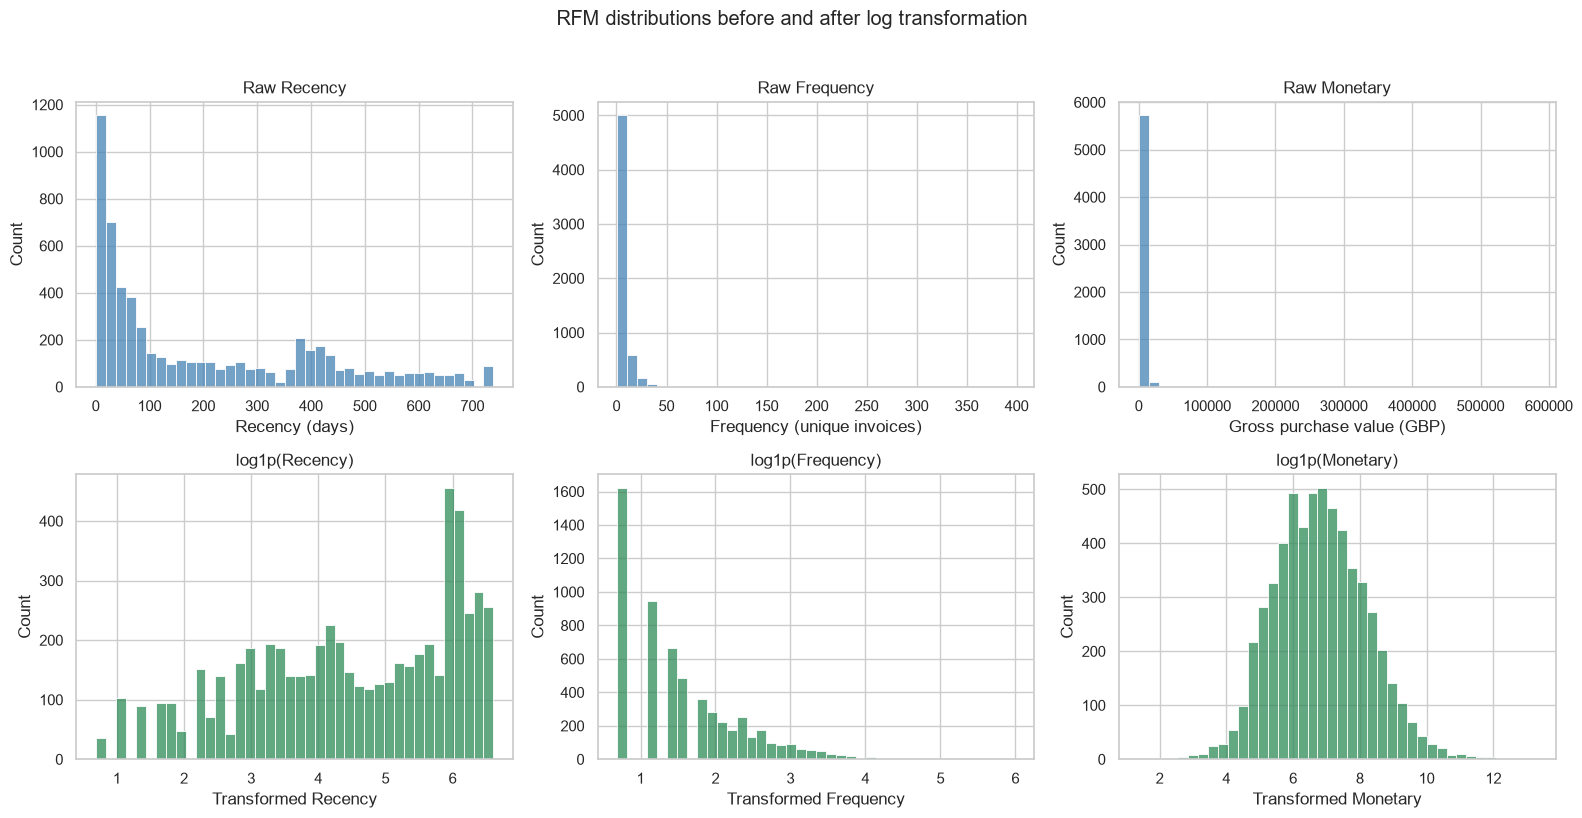

In [7]:
feature_labels = {
    "Recency": "Recency (days)",
    "Frequency": "Frequency (unique invoices)",
    "Monetary": "Gross purchase value (GBP)",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for column_index, column in enumerate(MODEL_COLUMNS):
    sns.histplot(
        rfm[column],
        bins=40,
        ax=axes[0, column_index],
        color="steelblue",
    )
    axes[0, column_index].set_title(f"Raw {column}")
    axes[0, column_index].set_xlabel(feature_labels[column])

    sns.histplot(
        np.log1p(rfm[column]),
        bins=40,
        ax=axes[1, column_index],
        color="seagreen",
    )
    axes[1, column_index].set_title(f"log1p({column})")
    axes[1, column_index].set_xlabel(f"Transformed {column}")

fig.suptitle("RFM distributions before and after log transformation", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
rfm_for_model = rfm[MODEL_COLUMNS].copy()
rfm_log = np.log1p(rfm_for_model)

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    columns=MODEL_COLUMNS,
    index=rfm.index,
)

display(rfm_scaled.describe().round(2))

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.47,-1.06,-3.93
25%,-0.77,-1.06,-0.71
50%,0.07,-0.20,-0.04
75%,0.96,0.65,0.65
max,1.39,5.48,4.66


## 6. K-Means: compare possible values of K

`K` is the number of clusters requested from K-Means. Values from 2 to 6 are compared with three diagnostics:

- **Silhouette score:** ranges from `-1` to `1`. Higher values mean customers are, on average, closer to their own cluster than to neighboring clusters. There is no universal `0.50` pass mark.
- **Davies–Bouldin index:** starts at `0`. Lower values indicate more compact and better-separated clusters.
- **Smallest cluster share:** checks whether a solution creates a very small group that may be difficult to interpret or use.

These are internal metrics. They measure geometric structure, not business value.

In [9]:
kmeans_rows = []

for cluster_count in range(2, 7):
    model = KMeans(
        n_clusters=cluster_count,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(rfm_scaled)

    kmeans_rows.append(
        {
            "Model": "K-Means",
            "K": cluster_count,
            "Silhouette": silhouette_score(rfm_scaled, labels),
            "DaviesBouldin": davies_bouldin_score(rfm_scaled, labels),
            "SmallestClusterShare": pd.Series(labels)
            .value_counts(normalize=True)
            .min(),
        }
    )

kmeans_results = pd.DataFrame(kmeans_rows)
display(kmeans_results.round(4))

,Model,K,Silhouette,DaviesBouldin,SmallestClusterShare
0,K-Means,2,0.4385,0.8719,0.3967
1,K-Means,3,0.3479,1.0351,0.2144
2,K-Means,4,0.3664,0.9289,0.2048
3,K-Means,5,0.3456,0.9513,0.0817
4,K-Means,6,0.3338,0.9612,0.0794


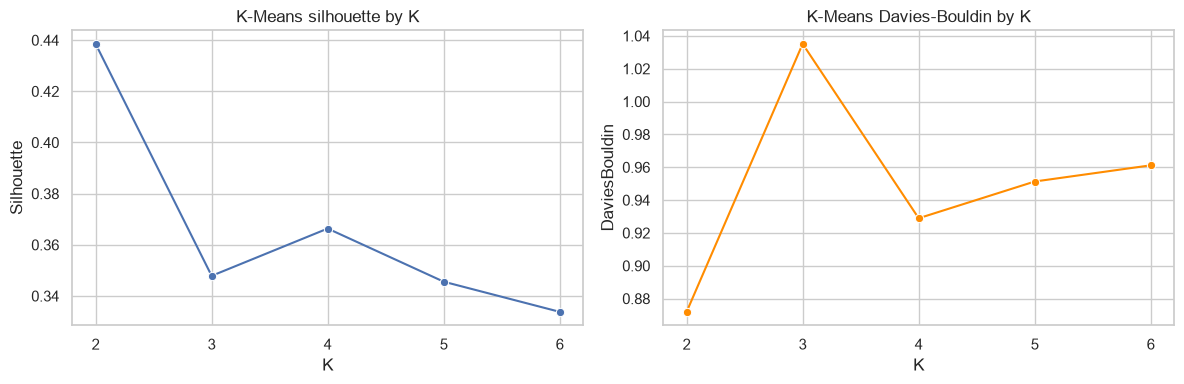

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(
    data=kmeans_results,
    x="K",
    y="Silhouette",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("K-Means silhouette by K")
axes[0].set_xticks(kmeans_results["K"])

sns.lineplot(
    data=kmeans_results,
    x="K",
    y="DaviesBouldin",
    marker="o",
    color="darkorange",
    ax=axes[1],
)
axes[1].set_title("K-Means Davies-Bouldin by K")
axes[1].set_xticks(kmeans_results["K"])

plt.tight_layout()
plt.show()

### K=2 for structure, K=4 for profiling

K-Means K=2 has the highest tested silhouette (`0.4385`). Ward K=2 has the lowest Davies-Bouldin score (`0.8191`, compared with `0.8719` for K-Means). Because the metrics do not name one universal winner, the safer conclusion is that both methods support a broad two-group structure.

K=4 is still useful for the project because:

- it separates the broad groups into more detailed behaviors;
- its smallest segment still contains about 20% of customers;
- the `n_init=20` project setting is highly repeatable across tested random seeds;
- the resulting profiles lead to distinct interpretations.

The final choice is therefore a trade-off: **K=2 describes the strongest geometry, while K=4 provides more useful profile detail.**

In [11]:
macro_labels = KMeans(
    n_clusters=2,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
).fit_predict(rfm_scaled)

macro_profiles = rfm.assign(MacroCluster=macro_labels).groupby(
    "MacroCluster"
).agg(
    CustomerCount=("MacroCluster", "size"),
    RecencyMedian=("Recency", "median"),
    FrequencyMedian=("Frequency", "median"),
    MonetaryMedian=("Monetary", "median"),
)
macro_profiles["CustomerSharePct"] = (
    macro_profiles["CustomerCount"] / len(rfm) * 100
)

display(macro_profiles.round(2))

,CustomerCount,RecencyMedian,FrequencyMedian,MonetaryMedian,CustomerSharePct
MacroCluster,,,,,
0,3546,291.5,2.0,414.16,60.33
1,2332,24.0,8.0,2852.50,39.67


### Initialization stability of K=4

K-Means begins from randomly selected centers. A weak solution may change when these starting points change.

Two checks are shown below:

1. A **single-start stress test** uses `n_init=1`. It shows what can happen if the algorithm accepts the result of only one starting position.
2. A **project-setting test** uses `n_init=20`, matching the final model. K-Means tries 20 starting positions and keeps the solution with the lowest within-cluster variation.

**Adjusted Rand Index (ARI)** compares two sets of customer labels without requiring the numeric cluster IDs to match. A value close to `1` means the groupings are very similar.

This tests sensitivity to initialization only. It does not prove stability across time or across a different customer sample.

In [12]:
chosen_k = 4

# Compare every run with the final multi-start solution.
reference_labels = KMeans(
    n_clusters=chosen_k,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
).fit_predict(rfm_scaled)

single_start_ari_scores = []
project_setting_ari_scores = []

for seed in range(20):
    single_start_labels = KMeans(
        n_clusters=chosen_k,
        init="k-means++",
        n_init=1,
        random_state=seed,
    ).fit_predict(rfm_scaled)
    single_start_ari_scores.append(
        adjusted_rand_score(reference_labels, single_start_labels)
    )

    project_setting_labels = KMeans(
        n_clusters=chosen_k,
        init="k-means++",
        n_init=20,
        random_state=seed,
    ).fit_predict(rfm_scaled)
    project_setting_ari_scores.append(
        adjusted_rand_score(reference_labels, project_setting_labels)
    )


def print_ari_summary(label, scores):
    print(label)
    print(f"  Minimum ARI: {min(scores):.4f}")
    print(f"  Median ARI: {np.median(scores):.4f}")
    print(f"  Maximum ARI: {max(scores):.4f}")


print_ari_summary("Single-start stress test (n_init=1)", single_start_ari_scores)
print_ari_summary("Project setting (n_init=20)", project_setting_ari_scores)

Single-start stress test (n_init=1)
  Minimum ARI: 0.5166
  Median ARI: 0.9908
  Maximum ARI: 0.9975
Project setting (n_init=20)
  Minimum ARI: 0.9931
  Median ARI: 0.9974
  Maximum ARI: 1.0000


## 7. Ward hierarchical clustering

Ward clustering repeatedly merges the two groups that create the smallest increase in within-cluster variation. Unlike K-Means, it creates a hierarchy that can be viewed as a tree.

The same values of K are evaluated so that Ward and K-Means are compared under similar conditions. Cluster numbers themselves have no meaning; only the grouping matters.

In [13]:
hierarchical_rows = []

for cluster_count in range(2, 7):
    model = AgglomerativeClustering(
        n_clusters=cluster_count,
        metric="euclidean",
        linkage="ward",
    )
    labels = model.fit_predict(rfm_scaled)

    hierarchical_rows.append(
        {
            "Model": "Hierarchical (Ward)",
            "K": cluster_count,
            "Silhouette": silhouette_score(rfm_scaled, labels),
            "DaviesBouldin": davies_bouldin_score(rfm_scaled, labels),
            "SmallestClusterShare": pd.Series(labels)
            .value_counts(normalize=True)
            .min(),
        }
    )

hierarchical_results = pd.DataFrame(hierarchical_rows)
display(hierarchical_results.round(4))

,Model,K,Silhouette,DaviesBouldin,SmallestClusterShare
0,Hierarchical (Ward),2,0.4311,0.8191,0.2235
1,Hierarchical (Ward),3,0.3317,1.0852,0.2235
2,Hierarchical (Ward),4,0.3179,1.0107,0.2235
3,Hierarchical (Ward),5,0.2985,1.0374,0.0504
4,Hierarchical (Ward),6,0.2921,1.1106,0.0504


### Reading the dendrogram

A full tree with 5,878 leaves would be unreadable, so the chart compresses earlier branches into 20 terminal groups. Numbers in parentheses are customer counts inside those compressed groups, not cluster IDs.

The Y-axis is the Ward merge distance. Groups that merge high on the chart are more different. The dashed line is placed between the last two merge levels and illustrates a two-cluster cut. The tree is useful evidence for the broad K=2 structure, but it is not used to claim that K=4 is the natural answer.

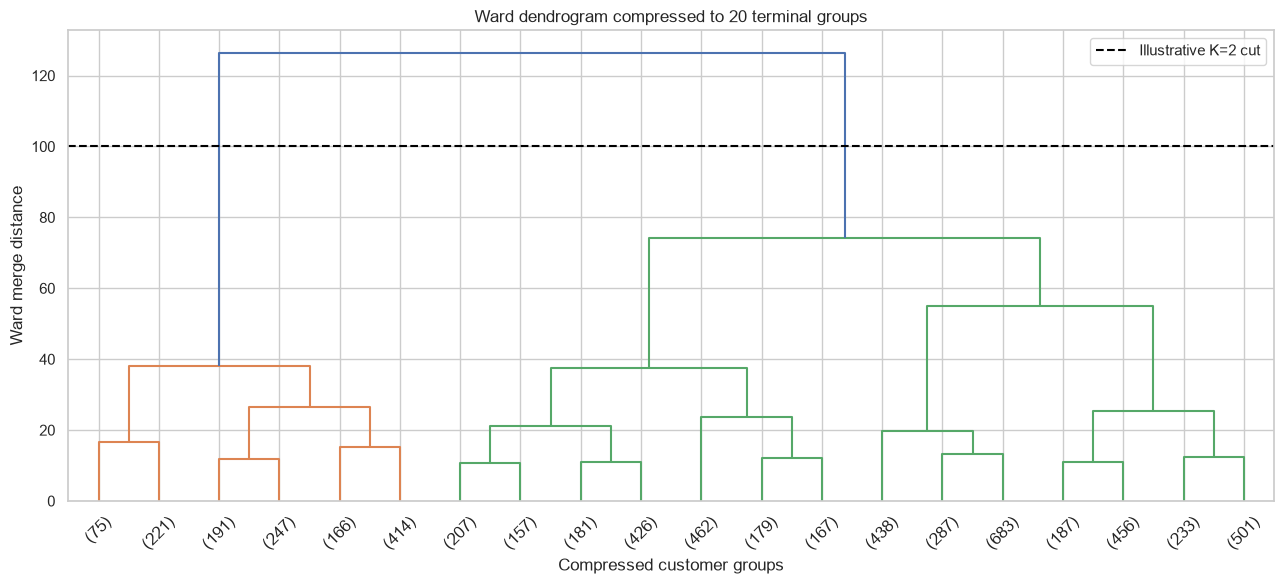

In [14]:
linkage_matrix = linkage(rfm_scaled, method="ward")
two_cluster_cut = (
    linkage_matrix[-1, 2] + linkage_matrix[-2, 2]
) / 2

plt.figure(figsize=(13, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True,
    leaf_rotation=45,
    color_threshold=two_cluster_cut,
)
plt.axhline(
    two_cluster_cut,
    color="black",
    linestyle="--",
    label="Illustrative K=2 cut",
)
plt.title("Ward dendrogram compressed to 20 terminal groups")
plt.xlabel("Compressed customer groups")
plt.ylabel("Ward merge distance")
plt.legend()
plt.tight_layout()
plt.show()

## 8. DBSCAN and density validation

DBSCAN does not require K in advance. It uses two main settings:

- **eps:** the maximum distance for two customers to be considered neighbors;
- **min_samples:** the minimum local neighborhood size needed to form a dense area.

Customers outside dense regions receive the label `-1`, called **noise**. Noise is not automatically an error, fraud case, or useless customer.

The grid below records:

- the number of clusters found;
- coverage, meaning the share of customers assigned to a non-noise cluster;
- non-noise silhouette as a secondary compactness diagnostic;
- the size of the smallest covered cluster.

A practical candidate must cover at least 80% of customers and give every covered cluster at least a 5% share. These are project choices, not universal scientific thresholds.

In [15]:
dbscan_rows = []

for eps_candidate in [0.25, 0.35, 0.45, 0.55, 0.65]:
    for min_samples_candidate in [6, 7, 12, 24]:
        candidate_labels = DBSCAN(
            eps=eps_candidate,
            min_samples=min_samples_candidate,
        ).fit_predict(rfm_scaled)

        non_noise_mask = candidate_labels != -1
        cluster_count = len(set(candidate_labels[non_noise_mask]))
        coverage = non_noise_mask.mean()

        if cluster_count >= 2:
            non_noise_silhouette = silhouette_score(
                rfm_scaled.loc[non_noise_mask],
                candidate_labels[non_noise_mask],
            )
            smallest_cluster_share = pd.Series(
                candidate_labels[non_noise_mask]
            ).value_counts(normalize=True).min()
        else:
            non_noise_silhouette = np.nan
            smallest_cluster_share = np.nan

        dbscan_rows.append(
            {
                "eps": eps_candidate,
                "min_samples": min_samples_candidate,
                "FoundClusters": cluster_count,
                "Coverage": coverage,
                "NoiseCount": int((~non_noise_mask).sum()),
                "SilhouetteWithoutNoise": non_noise_silhouette,
                "SmallestCoveredClusterShare": smallest_cluster_share,
            }
        )

dbscan_results = pd.DataFrame(dbscan_rows)
display(dbscan_results.round(4))

,eps,min_samples,FoundClusters,Coverage,NoiseCount,SilhouetteWithoutNoise,SmallestCoveredClusterShare
0,0.25,6,7,0.9354,380,0.0451,0.0009
1,0.25,7,5,0.9251,440,0.1087,0.0009
2,0.25,12,5,0.8801,705,0.1007,0.0193
3,0.25,24,4,0.7463,1491,0.1528,0.1190
4,0.35,6,3,0.9726,161,0.1561,0.1625
5,0.35,7,5,0.9695,179,0.0951,0.0007
6,0.35,12,3,0.9558,260,0.1638,0.1646
7,0.35,24,3,0.9214,462,0.1643,0.1625
8,0.45,6,2,0.9871,76,0.2786,0.2780
9,0.45,7,2,0.9850,88,0.2781,0.2775


### Select a practical DBSCAN setting, then run a DBCV check

The parameter table is first filtered using practical rules: acceptable customer coverage, at least two clusters, and no extremely small cluster. Non-noise silhouette is only the final tie-breaker among settings that pass those rules. It is not directly comparable with the K-Means silhouette because customers labelled as noise are excluded.

**DBCV (Density-Based Clustering Validation)** is then used as a density-specific post-fit check for the selected setting. It ranges approximately from `-1` to `1`:

- positive and higher values support well-separated density clusters;
- values near zero indicate weak density structure;
- negative values suggest that clusters overlap or are less internally connected than expected.

DBCV receives the full feature matrix and keeps the `-1` noise labels. Here it checks the practical candidate chosen above; it is not used to search the whole parameter grid because that calculation is much slower. The calculation may take around a minute on this dataset.

In [16]:
eligible_dbscan_results = dbscan_results.loc[
    (dbscan_results["Coverage"] >= 0.80)
    & (dbscan_results["FoundClusters"] >= 2)
    & (dbscan_results["SmallestCoveredClusterShare"] >= 0.05)
].dropna(subset=["SilhouetteWithoutNoise"])

if eligible_dbscan_results.empty:
    raise ValueError("No DBSCAN setting passed the practical selection rules.")

selected_dbscan_row = eligible_dbscan_results.sort_values(
    "SilhouetteWithoutNoise",
    ascending=False,
).iloc[0]

selected_eps = float(selected_dbscan_row["eps"])
selected_min_samples = int(selected_dbscan_row["min_samples"])

dbscan_model = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples,
)
dbscan_labels = dbscan_model.fit_predict(rfm_scaled)

dbscan_non_noise_mask = dbscan_labels != -1
dbscan_cluster_count = len(set(dbscan_labels[dbscan_non_noise_mask]))
dbscan_coverage = dbscan_non_noise_mask.mean()
dbscan_noise_count = int((~dbscan_non_noise_mask).sum())
dbscan_silhouette = silhouette_score(
    rfm_scaled.loc[dbscan_non_noise_mask],
    dbscan_labels[dbscan_non_noise_mask],
)
dbscan_dbcv = validity_index(
    rfm_scaled.to_numpy(dtype=np.float64),
    dbscan_labels.astype(np.int64),
    metric="euclidean",
)

selected_dbscan_report = pd.Series(
    {
        "eps": selected_eps,
        "min_samples": selected_min_samples,
        "FoundClusters": dbscan_cluster_count,
        "Coverage": dbscan_coverage,
        "NoiseCount": dbscan_noise_count,
        "SilhouetteWithoutNoise": dbscan_silhouette,
        "DBCV": dbscan_dbcv,
    },
    name="Selected DBSCAN",
)
display(selected_dbscan_report.to_frame().round(4))

,Selected DBSCAN
eps,0.4500
min_samples,24.0000
FoundClusters,2.0000
Coverage,0.9663
NoiseCount,198.0000
SilhouetteWithoutNoise,0.2841
DBCV,-0.6263


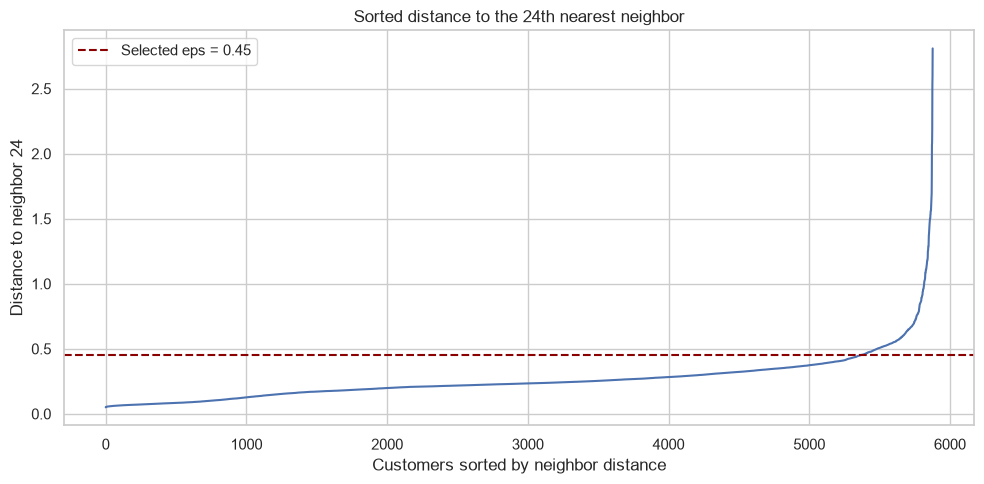

,CustomerCount,RecencyMedian,FrequencyMedian,MonetaryMedian,CustomerSharePct
DBSCANCluster,,,,,
-1 (Noise),198,22.5,19.0,16736.96,3.37
0,4093,61.0,4.0,1310.63,69.63
1,1587,390.0,1.0,229.64,27.00


In [17]:
neighbors = NearestNeighbors(n_neighbors=selected_min_samples)
neighbors.fit(rfm_scaled)
neighbor_distances, _ = neighbors.kneighbors(rfm_scaled)
selected_k_distances = np.sort(neighbor_distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(selected_k_distances)
plt.axhline(
    selected_eps,
    color="darkred",
    linestyle="--",
    label=f"Selected eps = {selected_eps:.2f}",
)
plt.title(
    f"Sorted distance to the {selected_min_samples}th nearest neighbor"
)
plt.xlabel("Customers sorted by neighbor distance")
plt.ylabel(f"Distance to neighbor {selected_min_samples}")
plt.legend()
plt.tight_layout()
plt.show()

dbscan_profiles = rfm.assign(DBSCANCluster=dbscan_labels).groupby(
    "DBSCANCluster"
).agg(
    CustomerCount=("DBSCANCluster", "size"),
    RecencyMedian=("Recency", "median"),
    FrequencyMedian=("Frequency", "median"),
    MonetaryMedian=("Monetary", "median"),
)
dbscan_profiles["CustomerSharePct"] = (
    dbscan_profiles["CustomerCount"] / len(rfm) * 100
)
dbscan_profiles = dbscan_profiles.rename(index={-1: "-1 (Noise)"})

display(dbscan_profiles.round(2))

### Why DBSCAN is not selected

Within the tested parameter grid, the selected practical setting finds two broad clusters and covers about 96.6% of customers. Its DBCV score is negative (`-0.6263`), so this setting does not show strong density separation. This conclusion applies to the selected setting in the current feature space; it does not mean DBSCAN can never work on another feature set or parameter range.

The more important business problem is the noise group. Its 198 customers have median RFM values of approximately **22.5 days, 19 invoices, and £16,736.96**. They are a sparse high-value tail, not obviously poor-quality records. Treating them only as anomalies would hide an important customer group.

DBSCAN is therefore useful as a diagnostic, but it is not the final segmentation model for this project.

## 9. Fair model summary and final choice

The table below is a summary, not a single leaderboard. K-Means and Ward silhouettes use every customer. DBSCAN silhouette uses only non-noise customers, while DBCV evaluates density structure including noise labels.

ARI between K-Means K=4 and Ward K=4 measures agreement between their assignments. It is not a model-quality score.

In [18]:
final_kmeans = KMeans(
    n_clusters=chosen_k,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
final_kmeans_labels = final_kmeans.fit_predict(rfm_scaled)

final_hierarchical = AgglomerativeClustering(
    n_clusters=chosen_k,
    metric="euclidean",
    linkage="ward",
)
final_hierarchical_labels = final_hierarchical.fit_predict(rfm_scaled)

model_agreement_ari = adjusted_rand_score(
    final_kmeans_labels,
    final_hierarchical_labels,
)

def metric_at_k(results, cluster_count, metric):
    return results.loc[results["K"] == cluster_count, metric].iloc[0]


model_summary = pd.DataFrame(
    [
        {
            "Model": "K-Means K=2",
            "Clusters": 2,
            "Coverage": 1.0,
            "Silhouette": metric_at_k(kmeans_results, 2, "Silhouette"),
            "DaviesBouldin": metric_at_k(kmeans_results, 2, "DaviesBouldin"),
            "DBCV": np.nan,
            "SilhouettePopulation": "All customers",
            "Role": "Highest-silhouette macro split",
        },
        {
            "Model": "K-Means K=4",
            "Clusters": 4,
            "Coverage": 1.0,
            "Silhouette": metric_at_k(kmeans_results, 4, "Silhouette"),
            "DaviesBouldin": metric_at_k(kmeans_results, 4, "DaviesBouldin"),
            "DBCV": np.nan,
            "SilhouettePopulation": "All customers",
            "Role": "Selected for detailed profiles",
        },
        {
            "Model": "Ward K=2",
            "Clusters": 2,
            "Coverage": 1.0,
            "Silhouette": metric_at_k(
                hierarchical_results, 2, "Silhouette"
            ),
            "DaviesBouldin": metric_at_k(
                hierarchical_results, 2, "DaviesBouldin"
            ),
            "DBCV": np.nan,
            "SilhouettePopulation": "All customers",
            "Role": "Lowest-Davies-Bouldin macro split",
        },
        {
            "Model": "Ward K=4",
            "Clusters": 4,
            "Coverage": 1.0,
            "Silhouette": metric_at_k(
                hierarchical_results, 4, "Silhouette"
            ),
            "DaviesBouldin": metric_at_k(
                hierarchical_results, 4, "DaviesBouldin"
            ),
            "DBCV": np.nan,
            "SilhouettePopulation": "All customers",
            "Role": "Four-cluster comparison",
        },
        {
            "Model": "DBSCAN selected setting",
            "Clusters": dbscan_cluster_count,
            "Coverage": dbscan_coverage,
            "Silhouette": dbscan_silhouette,
            "DaviesBouldin": np.nan,
            "DBCV": dbscan_dbcv,
            "SilhouettePopulation": "Non-noise customers",
            "Role": "Density diagnostic",
        },
    ]
)

display(model_summary.round(4))
print(f"K-Means K=4 vs Ward K=4 assignment ARI: {model_agreement_ari:.4f}")

,Model,Clusters,Coverage,Silhouette,DaviesBouldin,DBCV,SilhouettePopulation,Role
0,K-Means K=2,2,1.0000,0.4385,0.8719,NaN,All customers,Highest-silhouette macro split
1,K-Means K=4,4,1.0000,0.3664,0.9289,NaN,All customers,Selected for detailed profiles
2,Ward K=2,2,1.0000,0.4311,0.8191,NaN,All customers,Lowest-Davies-Bouldin macro split
3,Ward K=4,4,1.0000,0.3179,1.0107,NaN,All customers,Four-cluster comparison
4,DBSCAN selected setting,2,0.9663,0.2841,NaN,-0.6263,Non-noise customers,Density diagnostic


K-Means K=4 vs Ward K=4 assignment ARI: 0.5720


### Final model decision

**K-Means K=4 is selected for customer profiling.**

This choice is not based on claiming that K=4 has the highest silhouette. It is selected because the four groups are reasonably balanced and describe distinct levels of activity and value. With the final `n_init=20` setting, ARI stays between `0.9931` and `1.0000` across the tested seeds. The single-start stress test falls as low as `0.5166`, which is why using several starts matters.

Ward K=4 has a lower silhouette, and its assignment agreement with K-Means is moderate (`ARI = 0.5720`). The selected practical DBSCAN setting has negative DBCV and places a commercially valuable tail into noise.

## 10. Final customer profiles

Profiling returns to the original RFM units so the results can be read as days, invoices, and pounds. Medians describe a typical customer better than means when a segment contains extreme spenders.

Cluster IDs are arbitrary and can change after a rerun even when the customer groups stay almost the same. The code therefore assigns names from the profile ordering instead of attaching a fixed name to cluster 0, 1, 2, or 3:

- **High-Value Active:** highest median purchase value and high frequency.
- **Inactive One-Time:** longest median recency and low frequency.
- **Recent Developing:** more recent of the two remaining profiles.
- **Established At Risk:** the remaining profile, with several past purchases but longer recency.

The unnamed profile table should still be inspected before accepting these descriptions. “At Risk” is a behavioral description based on recency, not confirmed future churn.

In [19]:
customer_profiles = rfm.copy()
customer_profiles["Cluster"] = final_kmeans_labels

cluster_profile = customer_profiles.groupby("Cluster").agg(
    CustomerCount=("Cluster", "size"),
    RecencyMedian=("Recency", "median"),
    FrequencyMedian=("Frequency", "median"),
    GrossPurchaseValueMedian=("Monetary", "median"),
    GrossPurchaseValueMean=("Monetary", "mean"),
    ReturnEventShareMedian=("ReturnEventShare", "median"),
    ClusterGrossPurchaseValue=("Monetary", "sum"),
)

cluster_profile["CustomerSharePct"] = (
    cluster_profile["CustomerCount"] / len(customer_profiles) * 100
)
cluster_profile["GrossPurchaseValueSharePct"] = (
    cluster_profile["ClusterGrossPurchaseValue"]
    / customer_profiles["Monetary"].sum()
    * 100
)
cluster_profile["ReturnEventShareMedianPct"] = (
    cluster_profile["ReturnEventShareMedian"] * 100
)


def build_rfm_segment_name_map(
    profile,
    high_value_name,
    inactive_name,
    recent_name,
    established_name,
):
    """Name four RFM clusters from their relative profile values."""
    if len(profile) != 4:
        raise ValueError("This naming rule expects exactly four clusters.")

    high_value_cluster = profile["GrossPurchaseValueMedian"].idxmax()
    remaining = profile.drop(index=high_value_cluster)
    inactive_cluster = remaining["RecencyMedian"].idxmax()

    middle_clusters = [
        cluster
        for cluster in profile.index
        if cluster not in {high_value_cluster, inactive_cluster}
    ]
    recent_cluster = profile.loc[middle_clusters, "RecencyMedian"].idxmin()
    established_cluster = next(
        cluster for cluster in middle_clusters if cluster != recent_cluster
    )

    # These checks stop the notebook if the profiles no longer match the names.
    if (
        profile.loc[high_value_cluster, "FrequencyMedian"]
        != profile["FrequencyMedian"].max()
    ):
        raise ValueError("The high-value cluster is not also the most frequent.")
    if (
        profile.loc[inactive_cluster, "FrequencyMedian"]
        != profile["FrequencyMedian"].min()
    ):
        raise ValueError("The inactive cluster is not also the least frequent.")
    if (
        profile.loc[high_value_cluster, "RecencyMedian"]
        != profile["RecencyMedian"].min()
    ):
        raise ValueError("The high-value cluster is not also the most recent.")
    if not (
        profile.loc[recent_cluster, "RecencyMedian"]
        < profile.loc[established_cluster, "RecencyMedian"]
        and profile.loc[recent_cluster, "FrequencyMedian"]
        < profile.loc[established_cluster, "FrequencyMedian"]
        and profile.loc[recent_cluster, "GrossPurchaseValueMedian"]
        < profile.loc[established_cluster, "GrossPurchaseValueMedian"]
    ):
        raise ValueError(
            "The two middle profiles no longer match their segment names."
        )

    return {
        high_value_cluster: high_value_name,
        inactive_cluster: inactive_name,
        recent_cluster: recent_name,
        established_cluster: established_name,
    }


display(cluster_profile.round(2))

segment_name_map = build_rfm_segment_name_map(
    cluster_profile,
    high_value_name="High-Value Active",
    inactive_name="Inactive One-Time",
    recent_name="Recent Developing",
    established_name="Established At Risk",
)
customer_profiles["Segment"] = customer_profiles["Cluster"].map(
    segment_name_map
)

profile_columns = [
    "CustomerCount",
    "CustomerSharePct",
    "RecencyMedian",
    "FrequencyMedian",
    "GrossPurchaseValueMedian",
    "GrossPurchaseValueMean",
    "GrossPurchaseValueSharePct",
    "ReturnEventShareMedianPct",
]
segment_profile = cluster_profile[profile_columns].copy()
segment_profile["Segment"] = segment_profile.index.map(segment_name_map)
segment_profile = segment_profile.set_index("Segment")
segment_profile = segment_profile.sort_values(
    "GrossPurchaseValueMedian",
    ascending=False,
)

display(segment_profile.round(2))

,CustomerCount,RecencyMedian,FrequencyMedian,GrossPurchaseValueMedian,GrossPurchaseValueMean,ReturnEventShareMedian,ClusterGrossPurchaseValue,CustomerSharePct,GrossPurchaseValueSharePct,ReturnEventShareMedianPct
Cluster,,,,,,,,,,
0,1204,17.0,13.0,4965.48,10678.40,0.15,12856793.52,20.48,74.00,15.0
1,1455,186.0,4.0,1447.74,1945.08,0.12,2830096.17,24.75,16.29,12.5
2,1261,25.0,3.0,729.25,847.75,0.00,1069014.65,21.45,6.15,0.0
3,1958,404.5,1.0,272.04,316.09,0.00,618899.93,33.31,3.56,0.0


,CustomerCount,CustomerSharePct,RecencyMedian,FrequencyMedian,GrossPurchaseValueMedian,GrossPurchaseValueMean,GrossPurchaseValueSharePct,ReturnEventShareMedianPct
Segment,,,,,,,,
High-Value Active,1204,20.48,17.0,13.0,4965.48,10678.40,74.00,15.0
Established At Risk,1455,24.75,186.0,4.0,1447.74,1945.08,16.29,12.5
Recent Developing,1261,21.45,25.0,3.0,729.25,847.75,6.15,0.0
Inactive One-Time,1958,33.31,404.5,1.0,272.04,316.09,3.56,0.0


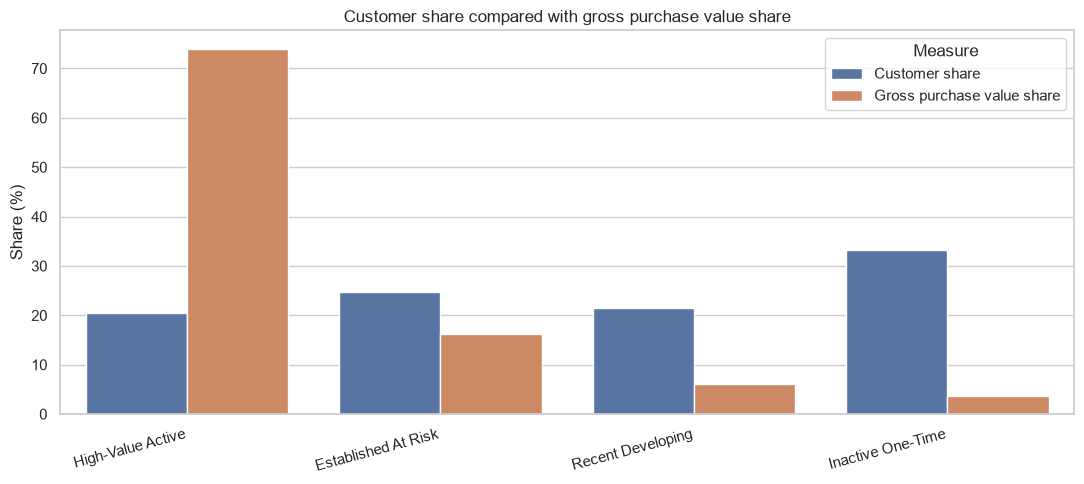

In [20]:
share_plot_data = (
    segment_profile[
        ["CustomerSharePct", "GrossPurchaseValueSharePct"]
    ]
    .reset_index()
    .melt(
        id_vars="Segment",
        var_name="Measure",
        value_name="SharePct",
    )
)
share_plot_data["Measure"] = share_plot_data["Measure"].map(
    {
        "CustomerSharePct": "Customer share",
        "GrossPurchaseValueSharePct": "Gross purchase value share",
    }
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=share_plot_data,
    x="Segment",
    y="SharePct",
    hue="Measure",
)
plt.title("Customer share compared with gross purchase value share")
plt.xlabel("")
plt.ylabel("Share (%)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

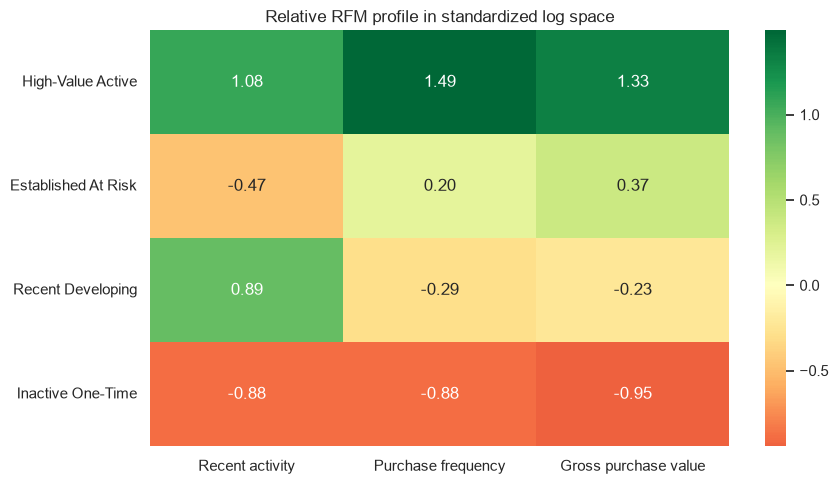

In [21]:
scaled_profile = rfm_scaled.copy()
scaled_profile["Segment"] = customer_profiles["Segment"]
heatmap_profile = scaled_profile.groupby("Segment").mean()

# Recency is reversed only for this chart so that higher means more recent.
heatmap_profile["Recency"] = -heatmap_profile["Recency"]
heatmap_profile = heatmap_profile.rename(
    columns={
        "Recency": "Recent activity",
        "Frequency": "Purchase frequency",
        "Monetary": "Gross purchase value",
    }
).reindex(segment_profile.index)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_profile,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
)
plt.title("Relative RFM profile in standardized log space")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Segment interpretation

**High-Value Active — 20.48% of customers, 74.00% of gross purchase value**  
Median customer: 17 days recency, 13 invoices, £4,965.48 purchase value. This is the core value group. The main goal is retention and service quality rather than aggressive discounting.

**Inactive One-Time — 33.31% of customers, 3.56% of gross purchase value**  
Median customer: 404.5 days recency, 1 invoice, £272.04 purchase value. This large group has low current value. Low-cost reactivation tests are more appropriate than expensive campaigns.

**Recent Developing — 21.45% of customers, 6.15% of gross purchase value**  
Median customer: 25 days recency, 3 invoices, £729.25 purchase value. These customers are active but have not yet reached the frequency or value of the strongest segment. Product discovery and second/next-purchase journeys may be useful.

**Established At Risk — 24.75% of customers, 16.29% of gross purchase value**  
Median customer: 186 days recency, 4 invoices, £1,447.74 purchase value. They have evidence of an established relationship but have not purchased recently. This is the clearest win-back candidate.

These actions are hypotheses suggested by behavior. The dataset does not contain campaign response or profit, so the notebook does not claim that a specific action will cause an improvement.

## 11. Time-based extension: do earlier segments matter later?

The source years overlap between 1 and 9 December 2010. Comparing them directly would count some transactions in both periods. Instead, two equal and non-overlapping 365-day windows are defined by date:

- **Period 1:** 1 December 2009 to 30 November 2010
- **Period 2:** 1 December 2010 to 30 November 2011

The final nine days in the source are excluded from this extension so both periods have equal length.

This section fits a separate one-year model for the time comparison. That is why its names, such as `High-value Loyal`, differ slightly from the combined-data names, such as `High-Value Active`.

The scaler and cluster centers are fit only on Period 1, then reused to assign Period 2 customers. `predict` here does not forecast future behavior; it assigns later RFM values to the nearest segment definition learned earlier. This keeps Period 2 values out of the fitted boundaries.

However, K-Means and `K=4` were chosen during the earlier combined-data exploration. This is therefore a **retrospective temporal consistency and outcome analysis**, not a completely untouched holdout validation.

In [22]:
def build_period_rfm(purchase_rows, period_end):
    return purchase_rows.groupby("Customer ID").agg(
        Recency=(
            "InvoiceDate",
            lambda dates: (
                period_end.normalize() - dates.max().normalize()
            ).days,
        ),
        Frequency=("Invoice", "nunique"),
        Monetary=("LineTotal", "sum"),
    )


period_1_start = pd.Timestamp("2009-12-01")
period_1_end = pd.Timestamp("2010-12-01")
period_2_start = pd.Timestamp("2010-12-01")
period_2_end = pd.Timestamp("2011-12-01")

period_1_purchases = purchases.loc[
    (purchases["InvoiceDate"] >= period_1_start)
    & (purchases["InvoiceDate"] < period_1_end)
].copy()
period_2_purchases = purchases.loc[
    (purchases["InvoiceDate"] >= period_2_start)
    & (purchases["InvoiceDate"] < period_2_end)
].copy()

period_1_rfm = build_period_rfm(period_1_purchases, period_1_end)
period_2_rfm = build_period_rfm(period_2_purchases, period_2_end)

period_1_customers = set(period_1_rfm.index)
period_2_customers = set(period_2_rfm.index)
retained_customers = period_1_customers & period_2_customers
newly_observed_period_2 = period_2_customers - period_1_customers

retained_period_2_value = period_2_rfm.loc[
    period_2_rfm.index.intersection(period_1_rfm.index),
    "Monetary",
].sum()

period_summary = pd.DataFrame(
    [
        {
            "Period": "Period 1",
            "ValidPurchaseRows": len(period_1_purchases),
            "ActiveCustomers": len(period_1_rfm),
            "DistinctInvoices": period_1_purchases["Invoice"].nunique(),
            "GrossPurchaseValue": period_1_purchases["LineTotal"].sum(),
        },
        {
            "Period": "Period 2",
            "ValidPurchaseRows": len(period_2_purchases),
            "ActiveCustomers": len(period_2_rfm),
            "DistinctInvoices": period_2_purchases["Invoice"].nunique(),
            "GrossPurchaseValue": period_2_purchases["LineTotal"].sum(),
        },
    ]
).set_index("Period")

customer_continuity = pd.Series(
    {
        "Customers active in both periods": len(retained_customers),
        "Period 1 customers with no Period 2 purchase": len(
            period_1_customers - period_2_customers
        ),
        "Newly observed in Period 2": len(newly_observed_period_2),
        "Period 1 to Period 2 customer retention": (
            len(retained_customers) / len(period_1_customers)
        ),
        "Returning customer share of Period 2 gross value": (
            retained_period_2_value / period_2_rfm["Monetary"].sum()
        ),
    },
    name="Value",
)

display(period_summary.round(2))
display(customer_continuity.to_frame().round(4))

,ValidPurchaseRows,ActiveCustomers,DistinctInvoices,GrossPurchaseValue
Period,,,,
Period 1,386732,4266,18437,8487577.37
Period 2,375666,4297,17754,8370018.45


,Value
Customers active in both periods,2713.0000
Period 1 customers with no Period 2 purchase,1553.0000
Newly observed in Period 2,1584.0000
Period 1 to Period 2 customer retention,0.6360
Returning customer share of Period 2 gross value,0.8211


### Overall period comparison

Active customer count is similar in both windows (4,266 versus 4,297), and gross purchase value decreases only about 1.4%. The customer base underneath those totals changes considerably:

- 2,713 Period 1 customers purchase again in Period 2;
- customer retention is 63.6%;
- 1,584 customer IDs are newly observed in Period 2;
- previously observed customers generate 82.1% of Period 2 gross purchase value.

“Newly observed” is used instead of “new customer” because customer history before the dataset is unknown. With only two annual windows, true reactivation also cannot be identified reliably.

In [23]:
period_scaler = StandardScaler()
period_1_scaled = period_scaler.fit_transform(
    np.log1p(period_1_rfm[MODEL_COLUMNS])
)

period_model = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
period_1_labels = period_model.fit_predict(period_1_scaled)

# Period 2 uses the scaler and cluster centers learned only from Period 1.
period_2_scaled = period_scaler.transform(
    np.log1p(period_2_rfm[MODEL_COLUMNS])
)
period_2_labels = period_model.predict(period_2_scaled)


def period_cluster_profile(period_rfm, labels):
    assigned = period_rfm.assign(Cluster=labels)
    profile = assigned.groupby("Cluster").agg(
        CustomerCount=("Cluster", "size"),
        RecencyMedian=("Recency", "median"),
        FrequencyMedian=("Frequency", "median"),
        GrossPurchaseValueMedian=("Monetary", "median"),
        GrossPurchaseValue=("Monetary", "sum"),
    )
    profile["CustomerSharePct"] = (
        profile["CustomerCount"] / len(assigned) * 100
    )
    profile["GrossPurchaseValueSharePct"] = (
        profile["GrossPurchaseValue"] / assigned["Monetary"].sum() * 100
    )
    return profile


period_1_cluster_profile = period_cluster_profile(
    period_1_rfm,
    period_1_labels,
)
period_2_cluster_profile = period_cluster_profile(
    period_2_rfm,
    period_2_labels,
)

period_segment_names = build_rfm_segment_name_map(
    period_1_cluster_profile,
    high_value_name="High-value Loyal",
    inactive_name="One-time / Lapsed",
    recent_name="Recent / Developing",
    established_name="Established Regulars",
)

period_1_profile = period_1_cluster_profile.rename(
    index=period_segment_names
)
period_2_profile = period_2_cluster_profile.rename(
    index=period_segment_names
)

temporal_metric_summary = pd.DataFrame(
    [
        {
            "Period": "Period 1 model fit",
            "Silhouette": silhouette_score(
                period_1_scaled, period_1_labels
            ),
            "DaviesBouldin": davies_bouldin_score(
                period_1_scaled, period_1_labels
            ),
        },
        {
            "Period": "Period 2 assigned with Period 1 model",
            "Silhouette": silhouette_score(
                period_2_scaled, period_2_labels
            ),
            "DaviesBouldin": davies_bouldin_score(
                period_2_scaled, period_2_labels
            ),
        },
    ]
).set_index("Period")

display(
    pd.concat(
        {"Period 1": period_1_profile, "Period 2": period_2_profile}
    ).round(2)
)
display(temporal_metric_summary.round(4))

CustomerCount  RecencyMedian  FrequencyMedian  \
         Cluster                                                               
Period 1 Established Regulars           1155           63.0              4.0   
         One-time / Lapsed              1445          173.0              1.0   
         Recent / Developing             921           14.0              2.0   
         High-value Loyal                745            9.0              9.0   
Period 2 Established Regulars           1089           63.0              4.0   
         One-time / Lapsed              1558          176.0              1.0   
         Recent / Developing             921           14.0              2.0   
         High-value Loyal                729            9.0              9.0   

                               GrossPurchaseValueMedian  GrossPurchaseValue  \
         Cluster                                                              
Period 1 Established Regulars                   1320.66          2004161.38   
         One-time / Lapsed                       258.34           431340.20   
         Recent / Developing                     509.75           572865.30   
         High-value Loyal                       3472.99          5479210.49   
Period 2 Established Regulars                   1276.00          1887933.69   
         One-time / Lapsed                       276.48           494994.62   
         Recent / Developing                     517.36           564505.46   
         High-value Loyal                       3509.43          5422584.68   

                               CustomerSharePct  GrossPurchaseValueSharePct  
         Cluster                                                             
Period 1 Established Regulars             27.07                       23.61  
         One-time / Lapsed                33.87                        5.08  
         Recent / Developing              21.59                        6.75  
         High-value Loyal                 17.46                       64.56  
Period 2 Established Regulars             25.34                       22.56  
         One-time / Lapsed                36.26                        5.91  
         Recent / Developing              21.43                        6.74  
         High-value Loyal                 16.97                       64.79

,Silhouette,DaviesBouldin
Period,,
Period 1 model fit,0.3413,0.9760
Period 2 assigned with Period 1 model,0.3377,0.9941


### Temporal consistency of the profiles

The Period 1 definitions produce very similar profiles in Period 2. For example, the High-value Loyal group is 17.5% of Period 1 customers and 17.0% of Period 2 customers, contributing roughly 65% of purchase value in both periods.

Silhouette changes from `0.3413` to `0.3377`, while Davies-Bouldin changes from `0.9760` to `0.9941`. These are not prediction-accuracy scores, but their similarity suggests that the same behavioral definitions remain recognizable in the later window.

In [24]:
period_1_segments = pd.Series(
    period_1_labels,
    index=period_1_rfm.index,
    name="Period1Segment",
).map(period_segment_names)
period_2_segments = pd.Series(
    period_2_labels,
    index=period_2_rfm.index,
    name="Period2Segment",
).map(period_segment_names)

period_2_value_for_period_1 = period_2_rfm["Monetary"].reindex(
    period_1_rfm.index
).fillna(0)
period_2_active_for_period_1 = period_2_rfm.index.to_series().reindex(
    period_1_rfm.index
).notna()

cohort_data = pd.DataFrame(
    {
        "Segment": period_1_segments,
        "Period1GrossPurchaseValue": period_1_rfm["Monetary"],
        "Period2GrossPurchaseValue": period_2_value_for_period_1,
        "Retained": period_2_active_for_period_1,
    }
)

cohort_summary = cohort_data.groupby("Segment").agg(
    Period1Customers=("Segment", "size"),
    RetainedCustomers=("Retained", "sum"),
    RetentionRate=("Retained", "mean"),
    Period1GrossPurchaseValue=("Period1GrossPurchaseValue", "sum"),
    Period2GrossPurchaseValueFromCohort=(
        "Period2GrossPurchaseValue",
        "sum",
    ),
)
cohort_summary["GrossValueRetention"] = (
    cohort_summary["Period2GrossPurchaseValueFromCohort"]
    / cohort_summary["Period1GrossPurchaseValue"]
)
cohort_summary["ShareOfAllPeriod2GrossValue"] = (
    cohort_summary["Period2GrossPurchaseValueFromCohort"]
    / period_2_rfm["Monetary"].sum()
)

display(cohort_summary.round(4))

,Period1Customers,RetainedCustomers,RetentionRate,Period1GrossPurchaseValue,Period2GrossPurchaseValueFromCohort,GrossValueRetention,ShareOfAllPeriod2GrossValue
Segment,,,,,,,
Established Regulars,1155,843,0.7299,2004161.383,1418254.691,0.7077,0.1694
High-value Loyal,745,714,0.9584,5479210.488,4577421.531,0.8354,0.5469
One-time / Lapsed,1445,555,0.3841,431340.202,345132.181,0.8001,0.0412
Recent / Developing,921,601,0.6526,572865.301,531971.580,0.9286,0.0636


### Following-period behavior by the original segment

The clearest result is the **High-value Loyal** cohort. It contains only 17.5% of Period 1 customers, yet:

- 95.8% purchase again in Period 2;
- the cohort generates about £4.58 million in Period 2;
- it contributes 54.7% of all Period 2 gross purchase value.

Established Regulars have 73.0% retention, Recent / Developing customers have 65.3%, and One-time / Lapsed customers have only 38.4%.

The One-time / Lapsed cohort retains about 80% of its aggregate purchase value despite weak customer retention. This should not be read as a healthy segment: a small number of larger returning customers can keep the total value high while most customers do not return.

These results are descriptive associations. They do not prove that segment membership causes future purchasing.

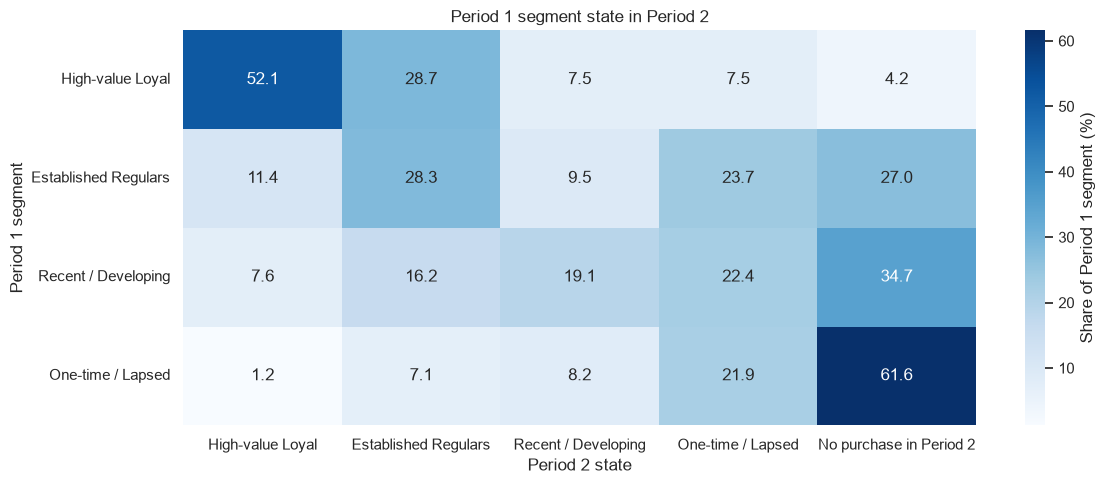

Period2Segment,High-value Loyal,Established Regulars,Recent / Developing,One-time / Lapsed,No purchase in Period 2
Period1Segment,,,,,
High-value Loyal,52.08,28.72,7.52,7.52,4.16
Established Regulars,11.43,28.31,9.52,23.72,27.01
Recent / Developing,7.60,16.18,19.11,22.37,34.74
One-time / Lapsed,1.25,7.06,8.24,21.87,61.59


In [25]:
period_2_state_for_period_1 = period_2_segments.reindex(
    period_1_segments.index
).fillna("No purchase in Period 2")

transition_percent = pd.crosstab(
    period_1_segments,
    period_2_state_for_period_1,
    normalize="index",
).mul(100)

transition_column_order = [
    "High-value Loyal",
    "Established Regulars",
    "Recent / Developing",
    "One-time / Lapsed",
    "No purchase in Period 2",
]
transition_percent = transition_percent.reindex(
    index=transition_column_order[:-1],
    columns=transition_column_order,
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    transition_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Share of Period 1 segment (%)"},
)
plt.title("Period 1 segment state in Period 2")
plt.xlabel("Period 2 state")
plt.ylabel("Period 1 segment")
plt.tight_layout()
plt.show()

display(transition_percent.round(2))

### Reading the transition table

Every row uses all customers from the original Period 1 segment as its denominator, so the final “No purchase” column is part of the transition result.

- 52.1% of High-value Loyal customers remain in that state and only 4.2% have no Period 2 purchase.
- 61.6% of One-time / Lapsed customers have no Period 2 purchase.
- Movement between groups is normal. The segments describe behavior inside a fixed window; they are not permanent labels attached to a person.

In [26]:
assert customer_profiles.index.is_unique
assert customer_profiles["Cluster"].nunique() == chosen_k
assert customer_profiles["Segment"].notna().all()
assert cluster_profile["CustomerCount"].sum() == len(customer_profiles)
assert np.isclose(cluster_profile["CustomerSharePct"].sum(), 100)
assert np.isclose(
    cluster_profile["GrossPurchaseValueSharePct"].sum(),
    100,
)
assert len(retained_customers) <= len(period_1_customers)
assert np.allclose(transition_percent.sum(axis=1), 100)

print("All notebook consistency checks passed.")

All notebook consistency checks passed.


## 12. Final conclusions and limitations

### What the project shows

1. The strongest tested solution is a two-group macro split, but useful business profiling needs more detail than that split provides.
2. K-Means K=4 gives four balanced and interpretable profiles. It is highly repeatable with the final multi-start setting, although the single-start stress test shows why one random start is not enough.
3. Density-based clustering is not a good final fit within the tested DBSCAN grid. The selected practical setting has negative DBCV, and it treats a sparse high-value tail as noise.
4. The strongest segment is small but economically dominant: High-Value Active customers are about one-fifth of the combined customer base and generate 74% of gross purchase value.
5. Earlier behavior is related to later activity. The High-value Loyal Period 1 cohort has 95.8% following-period purchase retention, while the One-time / Lapsed cohort has 38.4%.

### Limitations

- 22.8% of raw rows have no customer ID and cannot be included in customer profiles.
- Removing exact within-file repeats is an assumption because no line-item identifier is available.
- Monetary is gross positive purchase value. Returns are described separately but are not subtracted to create net revenue.
- RFM does not include product preference, profit, demographics, acquisition channel, or campaign response.
- Internal clustering metrics do not prove that a segment will respond to a business action.
- K=4 is an operational choice; K=2 remains the strongest silhouette-based split.
- The period extension is a retrospective consistency analysis, not an untouched holdout experiment.
- The time comparison uses two fixed windows. “No purchase observed” is not proof of permanent churn.

